# Visualización 3D del Espacio Latente (Texto vs Visual)

Este notebook reduce las 768 dimensiones de los embeddings de **MasQCLIP** y del **LVLM (Texto)** a 3 dimensiones usando **PCA**, y dibuja las conexiones entre ellos.

In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import sys
sys.path.append('/home/ubuntu/semantic-gaussians')
from opensplat3d.language import LanguageModel

# Rutas
out_dir = 'outputs/Replica/room1/20260508111114-36ef0444'
instances_path = f'{out_dir}/instances.json'
masqclip_path = f'{out_dir}/masqclip_embeddings.pth'

# Cargar datos
with open(instances_path, 'r') as f:
    instances_data = json.load(f)
    
# Asegurarnos de permitir la carga de pesos
visual_data = torch.load(masqclip_path, map_location='cpu', weights_only=False)
visual_embeddings = visual_data['embeddings']  # Forma: (190, 768)

print(f"Visual Embeddings Shape: {visual_embeddings.shape}")



Visual Embeddings Shape: (140, 768)


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Usar la clase nativa del pipeline para asegurar el mismo preprocesamiento y prompt_template
lang_model = LanguageModel("masqclip")

text_embeddings = []
vis_embeddings_filtered = []
labels = []
statuses = []

# Procesar cada instancia válida
for key, val in instances_data['instances'].items():
    # Extraer el índice original del final de la clave (ej. 'card_52' -> 52)
    idx = int(key.split('_')[-1])
    
    # Leer las 3 descripciones del archivo results.txt en vlm_debug
    debug_file = f'{out_dir}/vlm_debug/{idx}/results.txt'
    try:
        with open(debug_file, 'r') as df:
            # Extraer solo la parte de texto (antes de los dos puntos de la distancia)
            lines = df.readlines()
            descriptions = [l.rsplit(':', 1)[0].strip() for l in lines if l.strip()]
    except FileNotFoundError:
        continue
        
    if not descriptions:
        continue
    
    # Obtener embedding visual correspondiente y normalizarlo
    vis_emb = visual_embeddings[idx]
    if isinstance(vis_emb, np.ndarray):
        vis_emb = torch.from_numpy(vis_emb)
    vis_emb = vis_emb.to(device)
    vis_emb /= vis_emb.norm(dim=-1, keepdim=True)
    vis_emb_np = vis_emb.cpu().numpy()
    
    status = val.get('validation', {}).get('segmentation_status', 'unknown')
    
    # Procesar cada descripción del LVLM
    for i, desc in enumerate(descriptions):
        with torch.no_grad():
            # Formateamos con el mismo template ('A photo of a {}') que usa tu pipeline
            formatted_text = lang_model.prompt_template.format(desc)
            text_emb = lang_model.embed_text([formatted_text], normalize=True).to(device)
            
        text_embeddings.append(text_emb.squeeze(0).cpu().numpy())
        vis_embeddings_filtered.append(vis_emb_np)
        
        label_prefix = f"[Opción {i+1}] "
        labels.append(f"{key}: {label_prefix}{desc[:40]}...")
        statuses.append(status)

text_embeddings = np.array(text_embeddings)
vis_embeddings_filtered = np.array(vis_embeddings_filtered)
print(f"Procesados {len(text_embeddings)} pares de embeddings (3 descripciones por instancia).")



Procesados 342 pares de embeddings (3 descripciones por instancia).


In [3]:

# Concatenar todos los embeddings para que compartan el mismo espacio PCA
all_embeddings = np.vstack([text_embeddings, vis_embeddings_filtered])

# Calcular centroides globales para corregir el gap semántico en análisis posteriores
mu_text = np.mean(text_embeddings, axis=0, keepdims=True)
mu_vis = np.mean(vis_embeddings_filtered, axis=0, keepdims=True)

# Reducir a 3 dimensiones
pca = PCA(n_components=3)
all_embeddings_3d = pca.fit_transform(all_embeddings)

# Volver a separarlos
n = len(text_embeddings)
text_3d = all_embeddings_3d[:n]
vis_3d = all_embeddings_3d[n:]

# Configurar colores basados en el estado de segmentación
color_map = {
    "good-match": 'green',
    "over-segmented": 'orange',
    "under-segmented": 'purple',
    "partial-match": 'yellow',
    "no-match": 'red',
    "unknown": 'gray'
}
colors = [color_map.get(s, 'gray') for s in statuses]



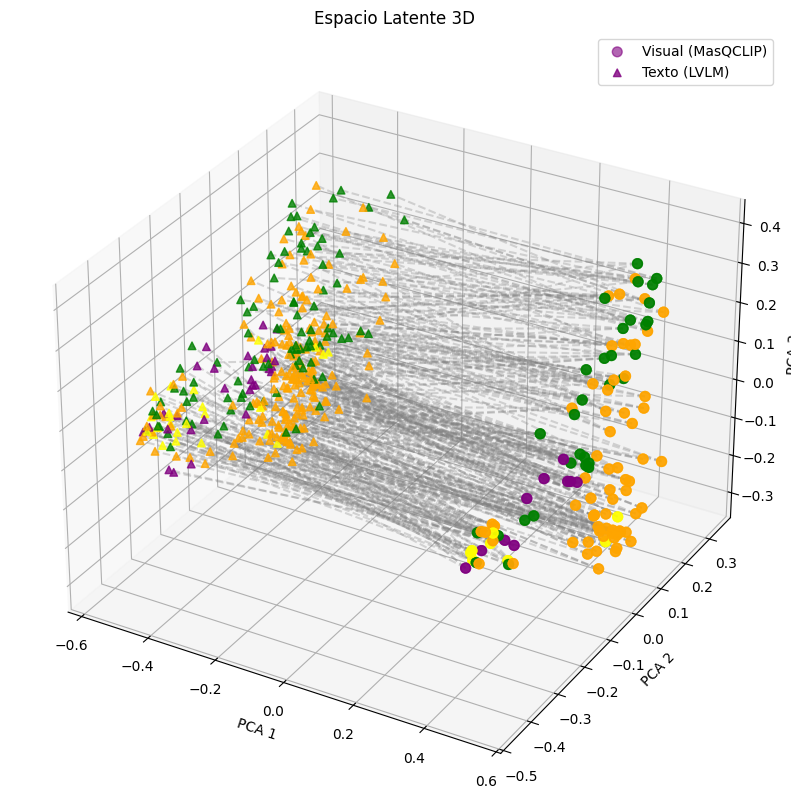

In [4]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Puntos visuales (esferas)
ax.scatter(vis_3d[:, 0], vis_3d[:, 1], vis_3d[:, 2], c=colors, marker='o', s=50, alpha=0.6, label='Visual (MasQCLIP)')

# Puntos de texto (triángulos)
ax.scatter(text_3d[:, 0], text_3d[:, 1], text_3d[:, 2], c=colors, marker='^', s=30, alpha=0.8, label='Texto (LVLM)')

# Líneas de conexión
for i in range(len(text_3d)):
    ax.plot([vis_3d[i, 0], text_3d[i, 0]], 
            [vis_3d[i, 1], text_3d[i, 1]], 
            [vis_3d[i, 2], text_3d[i, 2]], color='gray', linestyle='--', alpha=0.3)

ax.set_title('Espacio Latente 3D')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.legend()
plt.show()



---
## Visualización sin el Modality Gap (Centrado de Modalidades)
Para representar las cosas puramente en el espacio de la similitud semántica (Distancia Coseno) e ignorar el abismo que separa los textos de las imágenes en CLIP, restamos el "centro de gravedad" de cada modalidad por separado. Esto superpone ambos subespacios.

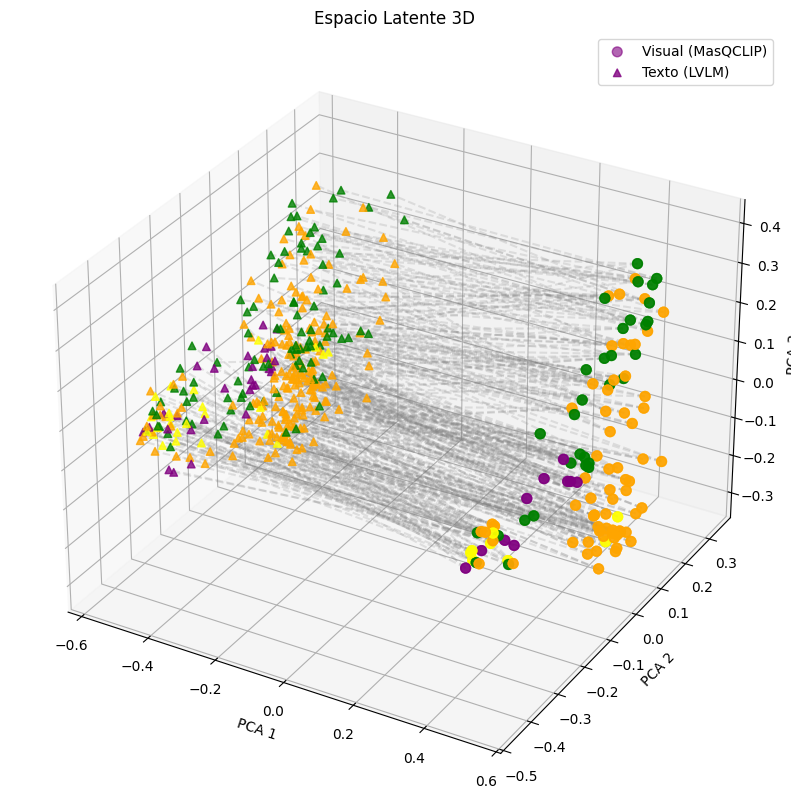

In [5]:

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Puntos visuales
ax.scatter(vis_3d[:, 0], vis_3d[:, 1], vis_3d[:, 2], c=colors, marker='o', s=50, alpha=0.6, label='Visual (MasQCLIP)')

# Puntos de texto
ax.scatter(text_3d[:, 0], text_3d[:, 1], text_3d[:, 2], c=colors, marker='^', s=30, alpha=0.8, label='Texto (LVLM)')

# Líneas de conexión
for i in range(len(text_3d)):
    ax.plot([vis_3d[i, 0], text_3d[i, 0]], 
            [vis_3d[i, 1], text_3d[i, 1]], 
            [vis_3d[i, 2], text_3d[i, 2]], color='gray', linestyle='--', alpha=0.2)

ax.set_title('Espacio Latente 3D')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.legend()
plt.show()




---
## Análisis Detallado de una Única Instancia
Aquí puedes analizar una instancia específica (por ejemplo `card_0`). Se representarán únicamente sus 3 descripciones frente a su propio embedding visual, para ver la varianza exacta y la distancia (Cosine Distance) entre las opciones generadas por el LVLM.

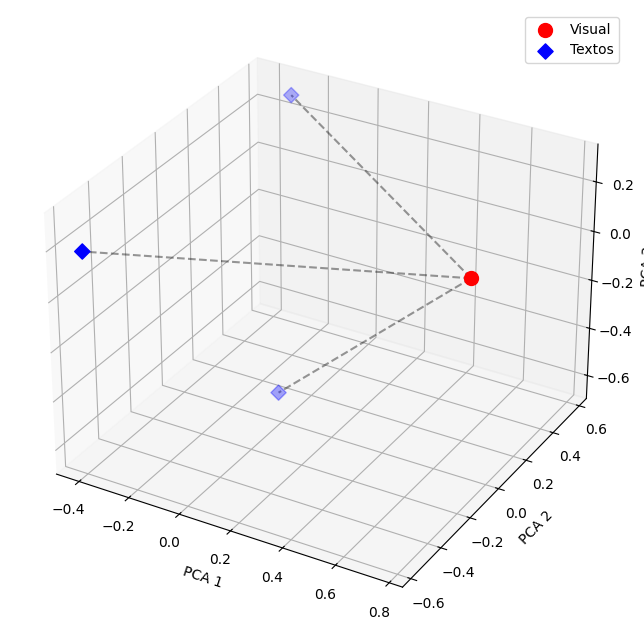

In [6]:

import torch.nn.functional as F

def analyze_instance(target_key, remove_gap=True):
    if target_key not in instances_data['instances']:
        print(f"Instancia {target_key} no encontrada.")
        return
        
    idx = int(target_key.split('_')[-1])
    debug_file = f'{out_dir}/vlm_debug/{idx}/results.txt'
    
    try:
        with open(debug_file, 'r') as df:
            lines = df.readlines()
            descriptions = [l.rsplit(':', 1)[0].strip() for l in lines if l.strip()]
    except FileNotFoundError:
        print(f"No se encontró el archivo de debug para {target_key}")
        return
        
    vis_emb = visual_embeddings[idx]
    if isinstance(vis_emb, np.ndarray):
        vis_emb = torch.from_numpy(vis_emb)
    vis_emb = vis_emb.to(device).float()
    vis_emb = F.normalize(vis_emb, p=2, dim=-1)
    
    text_embs = []
    for desc in descriptions:
        with torch.no_grad():
            formatted_text = lang_model.prompt_template.format(desc)
            t_emb = lang_model.embed_text([formatted_text], normalize=True).to(device)
        text_embs.append(t_emb.squeeze(0))
        
    text_embs = torch.stack(text_embs)
    
    if remove_gap:
        mu_t_tensor = torch.from_numpy(mu_text).float().to(device).squeeze(0)
        mu_v_tensor = torch.from_numpy(mu_vis).float().to(device).squeeze(0)
        vis_emb = F.normalize(vis_emb - mu_v_tensor, p=2, dim=-1)
        text_embs = F.normalize(text_embs - mu_t_tensor, p=2, dim=-1)
    
    similarities = (text_embs @ vis_emb.unsqueeze(-1)).squeeze(-1)
    distances = 1.0 - similarities
    
    all_pts = torch.cat([vis_emb.unsqueeze(0), text_embs], dim=0).cpu().numpy()
    pca_local = PCA(n_components=3)
    pts_3d = pca_local.fit_transform(all_pts)
    
    vis_3d_loc = pts_3d[0]
    texts_3d_loc = pts_3d[1:]
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter([vis_3d_loc[0]], [vis_3d_loc[1]], [vis_3d_loc[2]], color='red', s=100, label='Visual')
    ax.text(vis_3d_loc[0], vis_3d_loc[1], vis_3d_loc[2], "", color='red')
    
    ax.scatter(texts_3d_loc[:, 0], texts_3d_loc[:, 1], texts_3d_loc[:, 2], color='blue', marker='D', s=60, label='Textos')
    for i in range(len(descriptions)):
        ax.text(texts_3d_loc[i, 0], texts_3d_loc[i, 1], texts_3d_loc[i, 2], "", fontsize=8)
    
    for i in range(len(descriptions)):
        ax.plot([vis_3d_loc[0], texts_3d_loc[i, 0]], 
                [vis_3d_loc[1], texts_3d_loc[i, 1]], 
                [vis_3d_loc[2], texts_3d_loc[i, 2]], 'k--', alpha=0.4)
    
    #ax.set_title(f"Análisis Aislado de {target_key}")
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_zlabel('PCA 3')
    plt.legend()
    plt.show()

analyze_instance('pillow_49')


